> __Content modified under Creative Commons Attribution license CC-BY
> 4.0, code under BSD 3-Clause License © 2020 R.C. Cooper__

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Homework

## Problems [Part 1](./01_Interacting_with_Python.md)

1. Calculate some properties of a rectangular box that is 12.5"$\times$11"$\times$14" and weighs 31 lbs

    a. What is the volume of the box?
    
    b. What is the average density of the box?
    
    c. What is the result of the following logical operation, `volume>1000` (in inches^3)

In [2]:
L = 12.5
W = 11
H = 14
V = L*W*H
weight = 31
mass = 31/32.2 # slugs
density = mass/V


In [3]:
print('volume is {:1.0f} in^3'.format(V))
print('density is {:1.5f} slugs/in^3'.format(density))

V > 1000

volume is 1925 in^3
density is 0.00050 slugs/in^3


True

2. Use the variables given below, `str1` and `str2`, and check the following 

    a. `str1<str2`
    
    b. `str1==str2`
    
    c. `str1>str2`
    
    d. How could you force (b) to be true? [Hint](https://docs.python.org/3/library/stdtypes.html?highlight=str.lower#str.lower) or [Hint](https://docs.python.org/3/library/stdtypes.html?highlight=str.lower#str.upper)

In [4]:
str1 = 'Python'
str2 = 'python'

In [5]:
str1 < str2 

True

In [6]:
len(str1) == len(str2)

True

In [7]:
str1 > str2

False

3. The following code has an error, fix the error so that the correct result is returned:

```y is 20 and x is less than y```

```python
x="1"
y=20

if x<y and y==20:
    print('y is 20 and x is less than y')
else:
    print('x is not less than y')
```

In [8]:
x="1"
y=20

if int(x)<y and y==20:
    print('y is 20 and x is less than y')
else:
    print('x is not less than y')

y is 20 and x is less than y


In [9]:
int(x)

1

4. There is a commonly-used programming question that asks interviewees
   to build a [fizz-buzz](https://en.wikipedia.org/wiki/Fizz_buzz) result. 
   
   Here, you will build a similar program, but use the numbers from the
   class, **3255:** $3,~2,~5\rightarrow$ "computational", "mechanics",
   "rocks!". You should print out a list of numbers, if the number is
   divisible by 3, replace the 3 with "computational". If the number is
   divisible by 2, replace with "mechanics". If the number is divisible
   by 5, replace the number with "rocks!". If the number is divisible by
   a combination, then add both words e.g. 6 is divisible by 3 and 2, so
   you would print out "computational mechanics". 
   
   Here are the first 20 outputs your program should print, 
   
| index | printed output |
| ---   | ---            |
0 | Computational Mechanics Rocks!
1 | 1
2 | Mechanics 
3 | Computational 
4 | Mechanics 
5 | Rocks!
6 | Computational Mechanics
7 | 7
8 | Mechanics 
9 | Computational 
10 | Mechanics Rocks!
11 | 11
12 | Computational Mechanics
13 | 13
14 | Mechanics 
15 | Computational Rocks!
16 | Mechanics 
17 | 17
18 | Computational Mechanics
19 | 19

In [13]:
def fizzbuzz(x):
    result = ''
    if x%3==0:
        result += 'computational '
    if x%2==0:
        result += 'mechanics '
    if x%5==0:
        result += 'rocks!'
    if result == '':
        result = x
    return result

for i in range(20):
    print(fizzbuzz(i))

computational mechanics rocks!
1
mechanics 
computational 
mechanics 
rocks!
computational mechanics 
7
mechanics 
computational 
mechanics rocks!
11
computational mechanics 
13
mechanics 
computational rocks!
mechanics 
17
computational mechanics 
19


## Problems [Part 2](./02_Working_with_Python.md)

1. Create a function called `sincos(x)` that returns two arrays, `sinx` and `cosx` that return the sine and cosine of the input array, `x`. 

    a. Document your function with a help file in `'''help'''`
    
    b. Use your function to plot sin(x) and cos(x) for x=$0..2\pi$

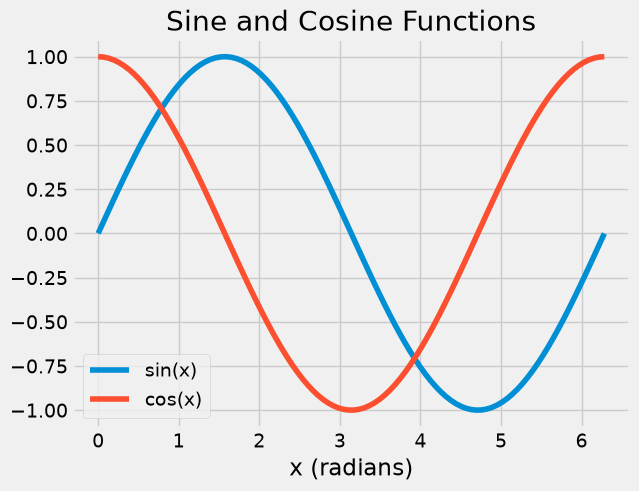

In [15]:
def sincos(x):
    '''Returns two arrays, the sine and cosine of x.'''
    return np.sin(x), np.cos(x)

x = np.linspace(0, 2*np.pi, 100)
s, c = sincos(x)
plt.plot(x, s, label='sin(x)')
plt.plot(x, c, label='cos(x)')
plt.title('Sine and Cosine Functions')
plt.xlabel('x (radians)')
plt.legend()
plt.show()

2. Use a for-loop to create a variable called `A_99`, where every element is the product
of the two indices from 0 to 9 e.g. A_99[3,2]=6 and A_99[4,4]=16. 

    
a. Calculate the mean and standard deviation of `A_99`

b. time your script that creates `A_99` takes its mean and standard deviation using `%%timeit`

In [29]:
%%timeit
A_99 = np.zeros((10,10))
for i in range(10):
    for j in range(10):
        A_99[i,j] = i*j

mean = np.mean(A_99)
std_dev = np.std(A_99)



17.1 μs ± 33.5 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


3. Use the two arrays, X and Y, given below to create A_99 using numpy array math rather than a for-loop.

In [28]:
X, Y = np.meshgrid(np.arange(10), np.arange(10))

In [30]:
%%timeit
A_99 = X * Y
mean = np.mean(A_99)
std_dev = np.std(A_99)

10.7 μs ± 31.9 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


b. Calculate the mean and standard deviation of `A_99`

c. time your script that creates `A_99` takes its mean and standard deviation using `%%timeit`    
    
d. create a filled contour plot of X, Y, A_99 [contourf plot documentation](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.contourf.html)

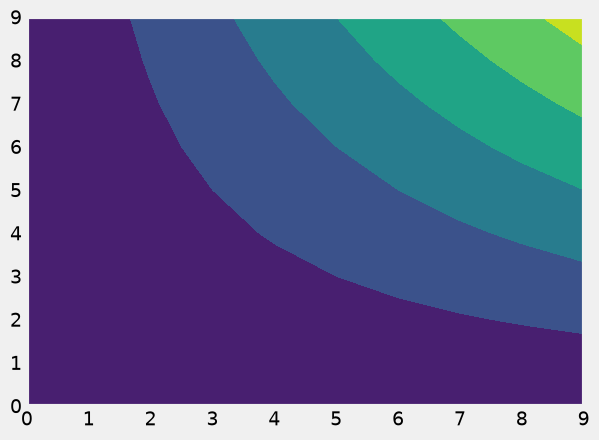

In [31]:
plt.contourf(X, Y, A_99)

4. The following linear interpolation function has an error. It is supposed to return y(x) given the the two points $p_1=[x_1,~y_1]$ and $p_2=[x_2,~y_2]$. Currently, it just returns and error.

```python
def linInterp(x,p1,p2):
    '''linear interplation function
    return y(x) given the two endpoints 
    p1=np.array([x1,y1])
    and
    p2=np.array([x2,y2])'''
    slope = (p2[2]-p1[2])/(p2[1]-p1[1])
    
    return p1[2]+slope*(x - p1[1])
```

In [32]:
def linInterp(x, p1, p2):
    '''linear interpolation function'''
    slope = (p2[1]-p1[1])/(p2[0]-p1[0])

    return p1[1] + slope*(x - p1[0])

## Problems [Part 3](./03_Numerical_error.md)

1. The growth of populations of organisms has many engineering and scientific applications. One of the simplest
models assumes that the rate of change of the population p is proportional to the existing population at any time t:

$\frac{dp}{dt} = k_g p$

where $t$ is time in years, and $k_g$ is growth rate in \[1/years\]. 

The world population has been increasing dramatically, let's make a prediction based upon the [following data](https://worldpopulationhistory.org/map/2020/mercator/1/0/25/) saved in [world_population_1900-2020.csv](../data/world_population_1900-2020.csv):


|year| world population |
|---|---|
|1900|1,578,000,000|
|1950|2,526,000,000|
|2000|6,127,000,000|
|2020|7,795,482,000|

a. Use a growth rate of $k_g=0.013$ [1/years] and compare the analytical solution (use initial condition p(1900) = 1578000000) to the Euler integration for time steps of 20 years from 1900 to 2020 (Hint: use method (1)- plot the two solutions together with the given data) 

b. Discussion question: If you decrease the time steps further and the solution converges, will it converge to the actual world population? Why or why not? 

**Note: We have used a new function `np.loadtxt` here. Use the `help` or `?` to learn about what this function does and how the arguments can change the output. In the next module, we will go into more details on how to load data, plot data, and present trends.**

In [33]:
import numpy as np
year, pop = np.loadtxt('../data/world_population_1900-2020.csv',skiprows=1,delimiter=',',unpack=True)
print('years=',year)
print('population =', pop)

years= [1900. 1950. 2000. 2020.]
population = [1.578000e+09 2.526000e+09 6.127000e+09 7.795482e+09]


In [34]:
print('average population changes 1900-1950, 1950-2000, 2000-2020')
print((pop[1:] - pop[0:-1])/(year[1:] - year[0:-1]))
print('average growth of 1900 - 2020')
print(np.mean((pop[1:] - pop[0:-1])/(year[1:] - year[0:-1])))

average population changes 1900-1950, 1950-2000, 2000-2020
[18960000. 72020000. 83424100.]
average growth of 1900 - 2020
58134700.0


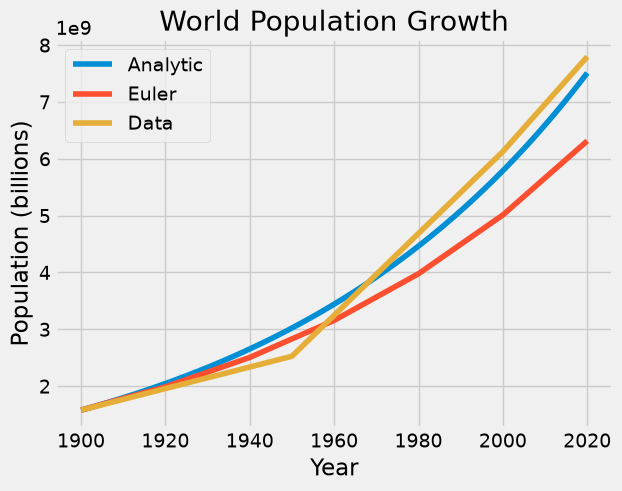

In [37]:
k_g = 0.013

#analytic solution
#p = Ce^0.013t

C = pop[0]
t_analytic = np.linspace(1900,2020, 100)
p_analytic = C*np.exp(k_g*(t_analytic-1900))

t_euler = np.arange(1900,2021,20)
dt = t_euler[1] - t_euler[0]
p_euler = np.zeros(len(t_euler))
p_euler[0] = pop[0]
for i in range(1,len(t_euler)):
    p_euler[i] = p_euler[i-1] + k_g*p_euler[i-1]*dt

plt.plot(t_analytic, p_analytic, label='Analytic')
plt.plot(t_euler, p_euler, label='Euler')
plt.plot(year, pop, label='Data')
plt.xlabel('Year')
plt.ylabel('Population (billions)')
plt.title('World Population Growth')
plt.legend()
plt.show()

B: It won't converge to the actual world population as it is just a mathmatical approximation and can't capture the complexities of actual population growht

__d.__ What happens to the numerical model as the number of timesteps increases? Does it look more like the analytical curve, $e^k(t-1900)$, or the measured population data, `pop`?

In [ ]:
# d: It looks more like the analytic solution than the measured population data.

2. In the freefall example you used smaller time steps to decrease the **truncation error** in our Euler approximation. Another way to decrease approximation error is to continue expanding the Taylor series. Consider the function f(x)

    $f(x)=e^x = 1+x+\frac{x^2}{2!}+\frac{x^3}{3!}+\frac{x^4}{4!}+...$

    We can approximate $e^x$ as $1+x$ (first order), $1+x+x^2/2$ (second order), and so on each higher order results in smaller error. 
    
    a. Use the given `exptaylor` function to approximate the value of exp(1) with a second-order Taylor series expansion. What is the relative error compared to `np.exp(1)`?
    
    b. Time the solution for a second-order Taylor series and a tenth-order Taylor series using `%%timeit`. How long would a 100,000-order series take (approximate this, **DON'T RUN** `exptaylor(1, 1000000)` )
    
    c. Plot the relative error as a function of the Taylor series expansion order from first order upwards. (Hint: use method (4) in the comparison methods from the "Truncation and roundoff error accumulation in log-log plot" figure)

In [44]:
from math import factorial
def exptaylor(x,n):
    '''Taylor series expansion about x=0 for the function e^x
    the full expansion follows the function
    e^x = 1+ x + x**2/2! + x**3/3! + x**4/4! + x**5/5! +...'''
    if n<1:
        print('lowest order expansion is 0 where e^x = 1')
        return 1
    else:
        ex = 1+x # define the first-order taylor series result
        for i in range(1,n):
            ex+=x**(i+1)/factorial(i+1) # add the nth-order result for each step in loop
        return ex
        

In [41]:
#a.
exp_1 = exptaylor(1,2)
relative_error = (np.abs(exp_1 - np.exp(1)))
print('Taylor series expansion of e^1 with n=2 is {:1.5f}'.format(exp_1))
print('Relative error is {:1.5f}'.format(relative_error))

Taylor series expansion of e^1 with n=2 is 2.50000
Relative error is 0.21828


In [ ]:
#b

In [42]:
%%timeit
exp_1 = exptaylor(1,2)

143 ns ± 0.329 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


In [43]:
%%timeit
exp_1 = exptaylor(1,10)

709 ns ± 8.45 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [47]:
# t = O(n^2)

A = 709*10**(-9) / 10**2

approximation = A * 100000**2

print('Approximate time to compute 100,000 order taylor series expansion is {:1.5f} seconds'.format(approximation))

Approximate time to compute 100,000 order taylor series expansion is 70.90000 seconds


In [49]:
N = np.arange(1, 30)
error = [np.abs(exptaylor(1,n) - np.exp(1)) for n in N]
error

[np.float64(0.7182818284590451),
 np.float64(0.2182818284590451),
 np.float64(0.05161516179237857),
 np.float64(0.009948495125712054),
 np.float64(0.0016151617923787498),
 np.float64(0.0002262729034896438),
 np.float64(2.7860205076724043e-05),
 np.float64(3.0586177750535626e-06),
 np.float64(3.0288585284310443e-07),
 np.float64(2.7312660577649694e-08),
 np.float64(2.260552189881082e-09),
 np.float64(1.7287637987806193e-10),
 np.float64(1.2285727990501982e-11),
 np.float64(8.149037000748649e-13),
 np.float64(5.0182080713057076e-14),
 np.float64(2.220446049250313e-15),
 np.float64(4.440892098500626e-16),
 np.float64(4.440892098500626e-16),
 np.float64(4.440892098500626e-16),
 np.float64(4.440892098500626e-16),
 np.float64(4.440892098500626e-16),
 np.float64(4.440892098500626e-16),
 np.float64(4.440892098500626e-16),
 np.float64(4.440892098500626e-16),
 np.float64(4.440892098500626e-16),
 np.float64(4.440892098500626e-16),
 np.float64(4.440892098500626e-16),
 np.float64(4.440892098500626e

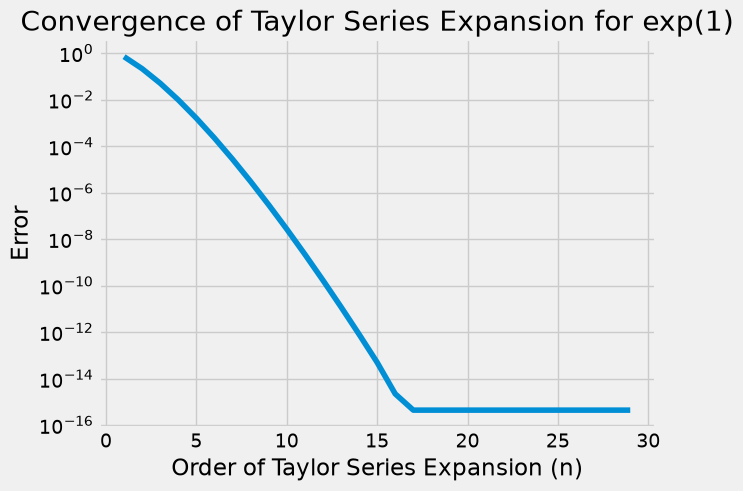

In [50]:
plt.semilogy(N, error)
plt.xlabel('Order of Taylor Series Expansion (n)')
plt.ylabel('Error')
plt.title('Convergence of Taylor Series Expansion for exp(1)')
plt.show()